![Astrofisica Computacional](../../new_logo.png)

# Computational Astrophysics –  ML Decision Trees I

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---
Taken from previous lectures of this course.


## Árboles de decisión

Usaremos **árboles de decisión** como algoritmo de aprendizaje automático (ML) para determinar el corrimiento al rojo de una galaxia a partir de sus índices de color fotométricos. Primero, describiremos cómo se haría esta tarea de forma clásica (es decir, sin ML) para comprender las posibles limitaciones de los métodos.



### El conjunto de datos

El método habitual para determinar el corrimiento al rojo de una galaxia implica obtener información de las líneas de emisión (visibles) y medir el desplazamiento de longitud de onda de estas líneas. Sin embargo, este método necesita un tiempo de procesamiento prolongado y no es eficiente para grandes volúmenes de datos. Además, muchas galaxias conocidas no tienen observaciones espectroscópicas, por lo que el método no es aplicable.

Por lo tanto, probaremos un procedimiento alternativo, utilizando las **magnitudes de flujo** en las bandas (u, g, r, i y z) reportadas en la base de datos Sloan Digital Sky Survey (SDSS) para estimar el corrimiento al rojo. El siguiente diagrama muestra las 5 bandas del SDSS en términos de longitud de onda.

<center>
<img
src="https://groklearning-cdn.com/modules/TYPnbyWbJVHGcaNudF4Nak/plot_sdss_filters_11.png"
>
</center>



Usaremos un conjunto de datos llamado 'sdss_galaxy_colors.npy', proporcionado como un archivo de tipo matriz estructurada [.npy](https://numpy.org/doc/stable/user/basics.rec.html). El archivo se lee usando la función [np.load()](https://numpy.org/doc/stable/reference/generated/numpy.load.html)

In [1]:
import numpy as np

data = np.load('sdss_galaxy_colors.npy')
data

array([(19.84132, 19.52656, 19.46946, 19.17955, 19.10763, b'QSO', 0.539301  , 6.543622e-05),
       (19.86318, 18.66298, 17.84272, 17.38978, 17.14313, b'GALAXY', 0.1645703 , 1.186625e-05),
       (19.97362, 18.31421, 17.47922, 17.0744 , 16.76174, b'GALAXY', 0.04190006, 2.183788e-05),
       ...,
       (19.82667, 18.10038, 17.16133, 16.5796 , 16.19755, b'GALAXY', 0.0784592 , 2.159406e-05),
       (19.98672, 19.75385, 19.5713 , 19.27739, 19.25895, b'QSO', 1.567295  , 4.505933e-04),
       (18.00024, 17.80957, 17.77302, 17.72663, 17.7264 , b'QSO', 0.4749449 , 6.203324e-05)],
      shape=(50000,), dtype=[('u', '<f8'), ('g', '<f8'), ('r', '<f8'), ('i', '<f8'), ('z', '<f8'), ('spec_class', 'S6'), ('redshift', '<f8'), ('redshift_err', '<f8')])

In [2]:
data.dtype

dtype([('u', '<f8'), ('g', '<f8'), ('r', '<f8'), ('i', '<f8'), ('z', '<f8'), ('spec_class', 'S6'), ('redshift', '<f8'), ('redshift_err', '<f8')])

The attribute `.dtype` gives the name of the features :

| dtype | Feature|
|:-:|:-:|
|`u` |u band filter|
|`g` |g band filter|
|`r` |r band filter|
|`i` |i band filter|
|`z` |z band filter|
|`spec_class` |spectral class|
|`redshift` |redshift|
|`redshift_err` |redshift error|


Se accede a cada función de la siguiente manera

In [3]:
data['u'] # para acceder al filtro u

array([19.84132, 19.86318, 19.97362, ..., 19.82667, 19.98672, 18.00024],
      shape=(50000,))

In [4]:
data['redshift'] # Redshift data

array([0.539301  , 0.1645703 , 0.04190006, ..., 0.0784592 , 1.567295  ,
       0.4749449 ], shape=(50000,))

El número total de muestras (galaxias) es

In [5]:
n = data.size
n

50000

---
### Correlación entre el corrimiento al rojo y los índices de color

El índice de color (o color astronómico) es la diferencia entre las magnitudes en dos filtros diferentes y da una aproximación al espectro del objeto observado. Los índices de color son útiles para la clasificación de estrellas y galaxias. Por ejemplo, un índice de color negativo `'u - g'` indica que el objeto es más brillante en las frecuencias ultravioleta que en las frecuencias verdes (recuerde la relación entre magnitudes y brillo).

Primero, trazaremos el comportamiento del corrimiento al rojo frente a algunos índices de color (u-g, g-i, r-i e i-z),

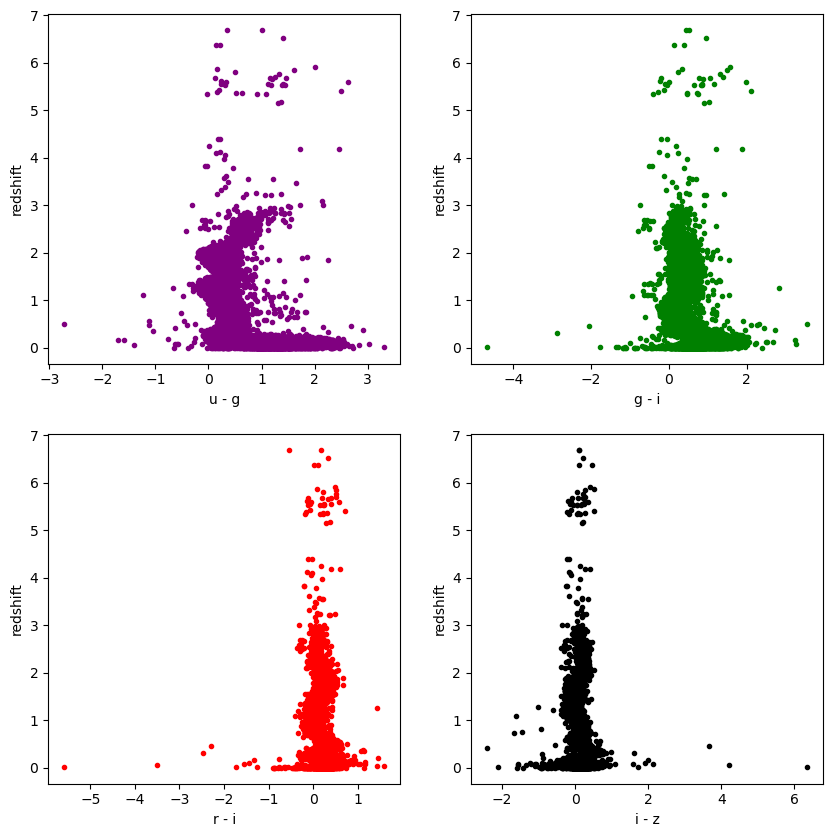

In [6]:
from matplotlib import pyplot as plt
%matplotlib inline

# Plot of the color indices u-g, g-i, r-i and i-z vs redshift
fig, ax = plt.subplots(2,2, figsize=(10,10))
ax[0,0].scatter(data['u']-data['g'], data['redshift'], color='purple', marker='.')
ax[0,1].scatter(data['g']-data['i'], data['redshift'], color='green', marker='.')
ax[1,0].scatter(data['r']-data['i'], data['redshift'], color='red', marker='.')
ax[1,1].scatter(data['i']-data['z'], data['redshift'], color='black', marker='.')
ax[0,0].set_ylabel(r'redshift')
ax[0,0].set_xlabel(r'u - g')
ax[0,1].set_ylabel(r'redshift')
ax[0,1].set_xlabel(r'g - i')
ax[1,0].set_ylabel(r'redshift')
ax[1,0].set_xlabel(r'r - i')
ax[1,1].set_ylabel(r'redshift')
ax[1,1].set_xlabel(r'i - z')
plt.show()

De estos gráficos se puede ver que no existe una relación clara entre el corrimiento al rojo y los índices de color. En particular, no podemos esperar una relación lineal entre estas variables.

Por tanto, exploraremos otros tipos de posibles relaciones. Por ejemplo, podemos probar una dependencia no lineal multivariada. Así, graficamos el comportamiento del corrimiento al rojo versus dos índices de color usando un mapa de colores y la función [matplotlib.pyplot.scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) con los argumentos `s`, `c` y `cmap`.

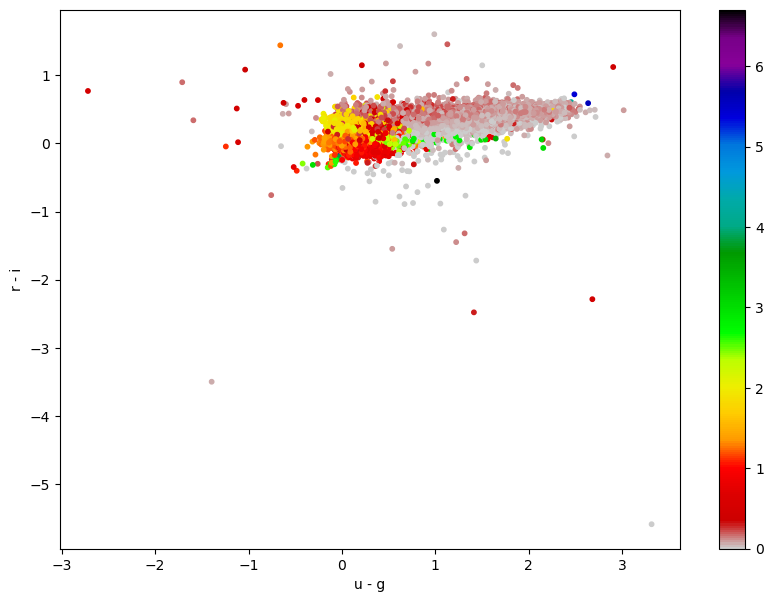

In [7]:
# Color gradient plot representign redshift
# vs. the color indices u-g and r-i

# Recommended colour map
cmap1 = plt.get_cmap('nipy_spectral_r')
plt.figure(figsize=(10,7))
plt.scatter(data['u']-data['g'],data['r']-data['i'], c=data['redshift'],s=10, cmap=cmap1)
plt.ylabel(r'r - i')
plt.xlabel(r'u - g')
plt.colorbar()
plt.show()

A partir de esta figura es posible identificar algunas regiones (razonablemente bien definidas) donde el corrimiento al rojo tiene valores similares. Por lo tanto, podemos esperar definir algunos 'contornos' para estimar el corrimiento al rojo en este diagrama, pero la incertidumbre en estas estimaciones puede ser alta.

---
### Árboles de decisión

Los **árboles de decisión** son una herramienta de aprendizaje automático que se puede utilizar para tareas de **clasificación** y **regresión**. En este tipo de algoritmo, un conjunto de características se asignan a un conjunto de objetivos. El entrenamiento del algoritmo se obtiene definiendo una serie de decisiones individuales representadas por nodos (bifurcación) en una estructura de árbol. Each decision uses one (and only one) of the features and the end point of every branch is one of the targets.

Un ejemplo de este tipo de estructura se ve en el artículo:

E. C. Vasconcellos et al. *Decision Tree Clasifiers for Star/Galaxy separation*. AJ 141, 189 (2011).



<center>
<img src="https://content.cld.iop.org/journals/1538-3881/141/6/189/revision1/aj385906f1_lr.jpg">
</center>

Las decisiones en cada rama se determinan a partir de los datos de entrenamiento y por el algoritmo de los árboles de decisión. En la práctica, cada algoritmo particular emplea una **métrica** para encontrar la decisión que dividirá los datos de forma más efectiva.


---

Ahora utilizaremos los índices de color fotométricos como los datos de entrada y los objetivos (datos de salida) serán los corrimientos al rojo. El entrenamiento del algoritmo deberá dar como resultado un árbol similar al que se muestra en la siguiente figura:

<center>
<img src="https://groklearning-cdn.com/modules/5PUcnT5fqRn5wTUXw7kg2B/decisiontree_1.png" width=450>
</center>

Tenga en cuenta que cada nodo implica sólo uno de los índices de color. Siguiendo una ruta particular en el árbol llegará a un valor objetivo particular, correspondiente al corrimiento al rojo de la muestra.



### Preparando el conjunto de datos

Para entrenar el algoritmo, definiremos los índices de color 'u-g', 'g-i', 'r-i' e 'i-z' y los usaremos para definir una matriz denominada `features`. De manera similar, definiremos una matriz llamada `targets` con la información del corrimiento al rojo.

In [ ]:
# Función que devuelve los 4 índices de color y los corrimientos al rojo.

# Crear los arrays con los cuatro indices 
# features = (nsize, 4)
# target = array redshifts

Como es habitual con las funciones de  `scikit-learn`, necesitamos que las características correspondan a columnas. Por lo tanto,

Ahora, dividimos estos conjuntos en subconjuntos de entrenamiento y prueba,

In [ ]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_targets, test_targets = train_test_split(features, targets, random_state=1803, test_size=0.4)

### Árboles de decisión en `SciKit Learn`

En `SciKit Learn`, usaremos la función [sklearn.tree.DecisionTreeRegressor](https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html).

In [ ]:
from sklearn.tree import DecisionTreeRegressor

d_tree = DecisionTreeRegressor(max_depth=5)

d_tree

Ahora entrenamos el modelo,

In [ ]:
d_tree.fit(train_features, train_targets)

Una vez que el modelo está completo, usamos el método `.predict()` para predecir el corrimiento al rojo de las muestras de prueba.

In [ ]:
predictions_d_tree = d_tree.predict(test_features)

#### Evaluación del modelo

Para evaluar el árbol de decisión, calcularemos la diferencia entre predicciones y objetivos. Estas diferencias se llaman **residuales** y encontraremos la mediana de estos valores,


eval_dec_tree = median$\{|$predictions$_i - $targets$_i|\}$ 


In [ ]:
#eval_d_tree =?

El resultado debería ser de $\approx 0.03$ en la mediana de los residuos indica que la mitad de las muestras de prueba tendrán un error de predicción de $< 0.03$ en el corrimiento al rojo.

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(d_tree, filled=True)

In [ ]:
# Para visualizar mejor el árbol, reduzcamos la profundidad del árbol. max_depth=5


In [ ]:
feature_names = ['[u-g]','[g-i]','[r-i]','[i-z]']

In [ ]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(d_tree, feature_names=feature_names, filled=True)

In [ ]:
fig.savefig("decistion_tree.pdf")